# Epidemic Spreading in Hyperbolic Space (ES-HS)
TFG Adrià Rojo, 2026

## Compilar eines

### SD Model

In [ ]:
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD

### Mercator

In [ ]:
! g++ -O3 -std=c++11 -I mercator/include/ mercator/src/embeddingS1_unix.cpp -o tools/mercator


### Epidemics

In [ ]:
! gfortran -O3 -march=native -funroll-loops \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics
! rm ./*.mod

In [ ]:
! ./tools/epidemics -h

In [ ]:
! ./tools/genSD -h

In [ ]:
! ./tools/genSD -d 1 -n 3000 -g 3 -k 0.4 -b 4 -s 12345 -o pipeline-output/net

In [ ]:
! ./tools/mercator -h

In [ ]:
! ./tools/mercator -o pipeline-output/ -b 1.10 -g 1.738 -s 12345 ./epidemics-tfg/nets/inf-openflights.edges
! ./tools/mercator -o pipeline-output/ -b 1.10 -g 1.738 -s 12345 ./epidemics-tfg/nets/inf-openflights_GC.edge


## Visualització

In [27]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [22]:
def read_hyperbolic_data(archivo_coords, archivo_edges):
    """
    Lee el grafo y las coordenadas hiperbólicas del formato S1/H2
    """
    # Leer grafo
    G = nx.read_edgelist(archivo_edges)
    
    # Leer coordenadas
    df = pd.read_csv(archivo_coords, sep='\\s+', comment='#', 
                     names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
    
    # Convertir Vertex a string
    df['Vertex'] = df['Vertex'].astype(str)
    # df = df.set_index('Vertex')
    # Leer parámetros del archivo
    params = {}
    with open(archivo_coords, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                parts = line.strip('# ').split(':')
                if len(parts) == 2:
                    key = parts[0].strip()
                    if (key.startswith('-')):
                        key = key[1:].strip()
                    try:
                        params[key] = float(parts[1].strip())
                    except ValueError:
                        params[key] = parts[1].strip()
    
    return G, df, params


def kappa_to_hyperbolic(kappa, kappa_min):
    """
    Convierte κ a coordenada radial hiperbólica
    r = (2/β) * ln(κ/κ_min)
    """
    return np.log(kappa / kappa_min)

def hyperbolic_to_poincare(r_hiperbolico):
    """
    Convierte radio hiperbólico a coordenada en disco de Poincaré
    r_poincare = tanh(r_hiperbolico/2)
    """
    return np.tanh(r_hiperbolico / 2)

def lorentz_boost(nodes: pd.DataFrame, index_node, kappa_min, precision=1e-10):
    """
    Aplica transformada de Lorentz para centrar un nodo específico.
    Trabaja con coordenadas basadas en κ.
    
    Parámetros:
    -----------
    nodos_dict : dict
        Diccionario con formato {id_nodo: {'kappa': κ, 'theta': θ}}
    index_node : str/int
        Identificador del nodo a centrar
    kappa_min : float
        Valor mínimo de κ en el dataset
    precision : float
        Precisión numérica
    
    Returns:
    --------
    dict : Diccionario con nuevas coordenadas {id_nodo: (r_nueva, theta_nueva)}
    """
    
    # Obtener datos del nodo a centrar
    node = nodes[nodes['Vertex'] == index_node].iloc[0]
    kappa_c = node['Inf.Kappa']
    theta_c = node['Inf.Theta']
    # Calcular radio hiperbólico del nodo central
    r_c = kappa_to_hyperbolic(kappa_c, kappa_min)
    
    # Convertir a coordenadas del hiperboloide
    x0_c = np.cosh(r_c)
    x1_c = np.sinh(r_c) * np.cos(theta_c)
    x2_c = np.sinh(r_c) * np.sin(theta_c)
    
    # Calcular parámetros del boost
    norm = np.sqrt(x1_c**2 + x2_c**2)
    
    if norm > precision:
        u1 = x1_c / norm
        u2 = x2_c / norm
        gamma = x0_c
        beta_boost = np.sqrt(1 - 1/gamma**2) if gamma >= 1 else 0
    else:
        # El nodo ya está en el centro
        return {nodo: (kappa_to_hyperbolic(datos['Inf.Kappa'], kappa_min), datos['Inf.Theta']) 
                for nodo, datos in nodes.items()}
    
    # Aplicar transformación a todos los nodos
    nuevos_nodos = []
    for nodo_id, datos in nodes.iterrows():
        kappa = datos['Inf.Kappa']
        theta = datos['Inf.Theta']
        vertex = datos['Vertex']
        
        # Calcular radio hiperbólico
        r = kappa_to_hyperbolic(kappa, kappa_min)
        
        # Convertir a hiperboloide
        x0 = np.cosh(r)
        x1 = np.sinh(r) * np.cos(theta)
        x2 = np.sinh(r) * np.sin(theta)
        
        # Producto escalar espacial
        x_dot_u = x1*u1 + x2*u2
        
        # Aplicar boost
        x0_nueva = gamma * x0 - gamma * beta_boost * x_dot_u
        x1_nueva = x1 + (gamma - 1) * x_dot_u * u1 - gamma * beta_boost * x0 * u1
        x2_nueva = x2 + (gamma - 1) * x_dot_u * u2 - gamma * beta_boost * x0 * u2
        
        # Asegurar x0_nueva >= 1
        x0_nueva = max(x0_nueva, 1.0)
        
        # Convertir de vuelta a coordenadas hiperbólicas
        r_nueva = np.arccosh(x0_nueva)
        
        # Calcular nuevo ángulo
        if r_nueva > precision:
            sinh_r = np.sinh(r_nueva)
            if sinh_r > 0:
                cos_theta = x1_nueva / sinh_r
                sin_theta = x2_nueva / sinh_r
                cos_theta = np.clip(cos_theta, -1.0, 1.0)
                sin_theta = np.clip(sin_theta, -1.0, 1.0)
                theta_nueva = np.arctan2(sin_theta, cos_theta)
            else:
                theta_nueva = 0.0
        else:
            theta_nueva = 0.0
        
        nuevos_nodos.append({'Vertex': vertex, 'Inf.Kappa': np.exp(r_nueva)*kappa_min, 'Inf.Theta': theta_nueva})
    
    new_df = pd.DataFrame(nuevos_nodos)
    new_df['Vertex'] = new_df['Vertex'].astype(str)
    return new_df

def poincare_disc(data: pd.DataFrame, kappa_min:float, mark_nodes: list[str] = [], net: nx.Graph = None):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    x_orig = []
    y_orig = []
    kappa_vals = []
    positions = {}
    for nodo_id, node_data in data.iterrows():
        # Para la visualización original, usamos los datos del diccionario original
        r_orig = kappa_to_hyperbolic(node_data['Inf.Kappa'], kappa_min)
        r_poincare = hyperbolic_to_poincare(r_orig)
        x = r_poincare * np.cos(node_data['Inf.Theta'])
        y = r_poincare * np.sin(node_data['Inf.Theta'])
        positions[node_data['Vertex']] = (x, y)
    
        x_orig.append(x)
        y_orig.append(y)
        if (r_poincare < 0.6):
            ax.annotate(node_data['Vertex'], (x, y))
        if (r_orig == 0):
            kappa_vals.append(-1)
        else:
            kappa_vals.append(np.log10(r_orig))
    
    scatter = ax.scatter(x_orig, y_orig, c=kappa_vals, cmap='viridis', 
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3, vmin=-1, vmax=1)
    if (net):
        for a, b in net.edges():
            xa, ya = positions[a]
            xb, yb = positions[b]
            ax.add_line(plt.Line2D([xa, xb], [ya, yb], linewidth=0.1, color='#00000030'))
    circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    ax.add_patch(circle)
    
    for mark_node in mark_nodes:
        mark_data = data[data['Vertex'] == mark_node].iloc[0]
        if not transformed:
            r_central_orig = kappa_to_hyperbolic(mark_data['Inf.Kappa'], kappa_min)
        else:
            r_central_orig = mark_data['Inf.Kappa']

        r_poincare_central = hyperbolic_to_poincare(r_central_orig)
        x_central = r_poincare_central * np.cos(mark_data['Inf.Theta'])
        y_central = r_poincare_central * np.sin(mark_data['Inf.Theta'])
        ax.plot(x_central, y_central, 'r*', markersize=15, markeredgecolor='black')

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='log10(κ)')
    plt.show()
    plt.close(fig)

def poincare_epidemic_disc(data: pd.DataFrame, kappa_min:float, transformed:bool, state: dict[str, str], filename: str = None, time:str = None):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    x_orig_red = []
    y_orig_red = []
    x_orig_white = []
    y_orig_white = []

    for nodo_id, node_data in data.iterrows():
        # Para la visualización original, usamos los datos del diccionario original
        if not transformed:
            r_orig = kappa_to_hyperbolic(node_data['Inf.Kappa'], kappa_min)
        else:
            r_orig = node_data['Inf.Kappa']
        r_poincare = hyperbolic_to_poincare(r_orig)
        x = r_poincare * np.cos(node_data['Inf.Theta'])
        y = r_poincare * np.sin(node_data['Inf.Theta'])
        if (state[node_data['Vertex']] == 'I'): # infected
            x_orig_red.append(x)
            y_orig_red.append(y)
        elif (state[node_data['Vertex']] == 'H'):
            x_orig_white.append(x)
            y_orig_white.append(y)
    
    ax.scatter(x_orig_red, y_orig_red, s=15, c='red')
    ax.scatter(x_orig_white, y_orig_white, s=15, alpha=0.5, linewidth=0.3, c='white', edgecolors='black')
    circle = plt.Circle((0, 0), 1, fill=False, color='black', linestyle='-')
    ax.add_patch(circle)
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if (time is not None):
        ax.set_title(f"t={time:.03f}")
    if (filename):
        fig.savefig(filename)
    else:
        plt.show()
    plt.close(fig)

        


In [35]:
coords_file = "./pipeline-output/.inf_coord"
edges_file = "./epidemics-tfg/nets/inf-openflights_GC.edge"
events_file = './pipeline-output/events-inf-openflights_GC-SIR-I=   0.50000-R=   1.00000-S=12345.dat'
# Leer datos
G, df, params = read_hyperbolic_data(coords_file, edges_file)
distances = []
for a, b in tqdm(G.edges):
    na = df[df['Vertex'] == a].iloc[0]
    nb = df[df['Vertex'] == b].iloc[0]

    ka = kappa_to_hyperbolic(na['Inf.Kappa'], params['kappa_min'])
    kb = kappa_to_hyperbolic(nb['Inf.Kappa'], params['kappa_min'])

    ra = hyperbolic_to_poincare(ka)
    rb = hyperbolic_to_poincare(kb)

    za = ra*np.exp(1j*na['Inf.Theta'])
    zb = rb*np.exp(1j*nb['Inf.Theta'])

    d = {'a': a, 'b': b, 'weight': 1/np.arccosh(1+(2*np.abs(za-zb)**2)/((1-ra**2)*(1-rb**2)))}
    distances.append(d)

nodes_dist = pd.DataFrame(distances)

100%|██████████| 15645/15645 [00:06<00:00, 2281.92it/s]


In [40]:
nodes_dist.to_csv(f"{edges_file}_weight", sep='\t', header=False, index=False)

/tmp/ipykernel_17309/227574461.py:191: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


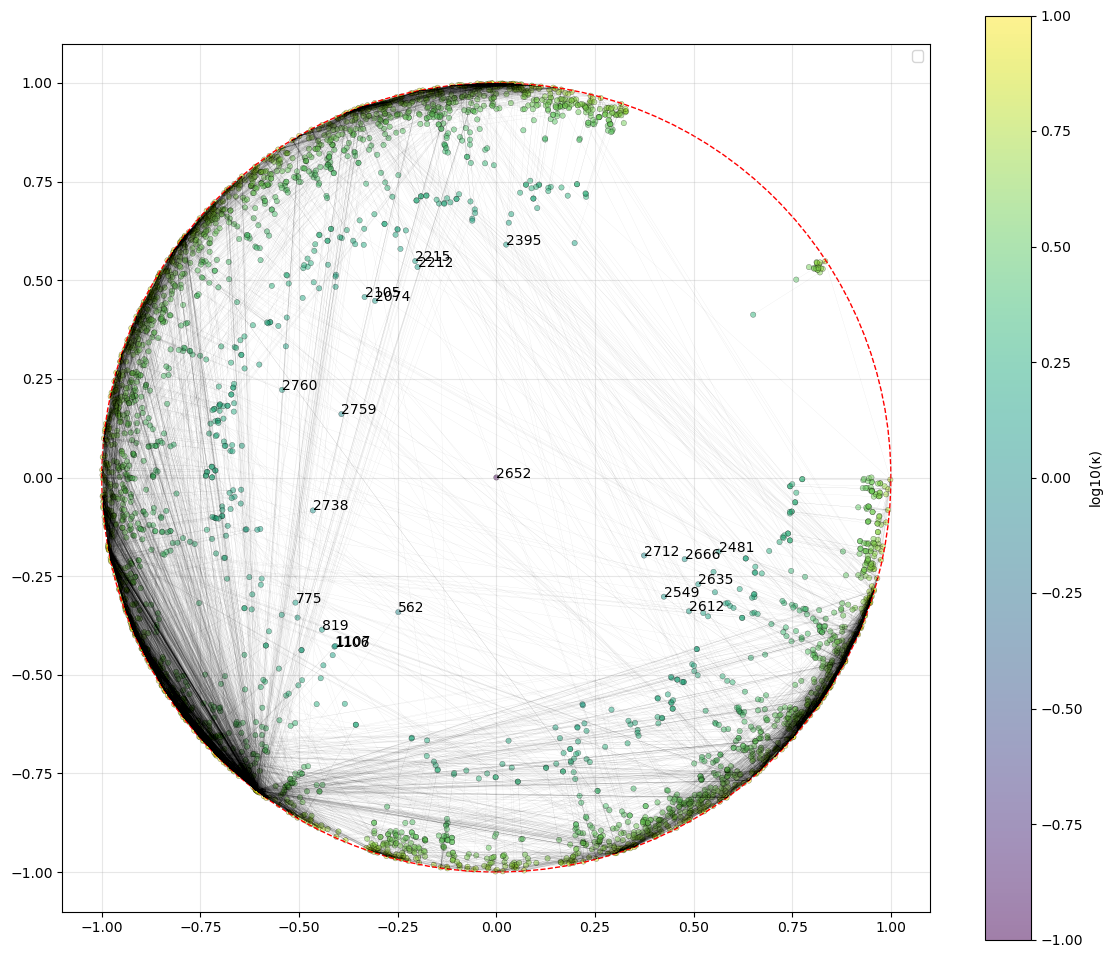

In [23]:
poincare_disc(df, params['kappa_min'], net=G)

/tmp/ipykernel_17309/227574461.py:191: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


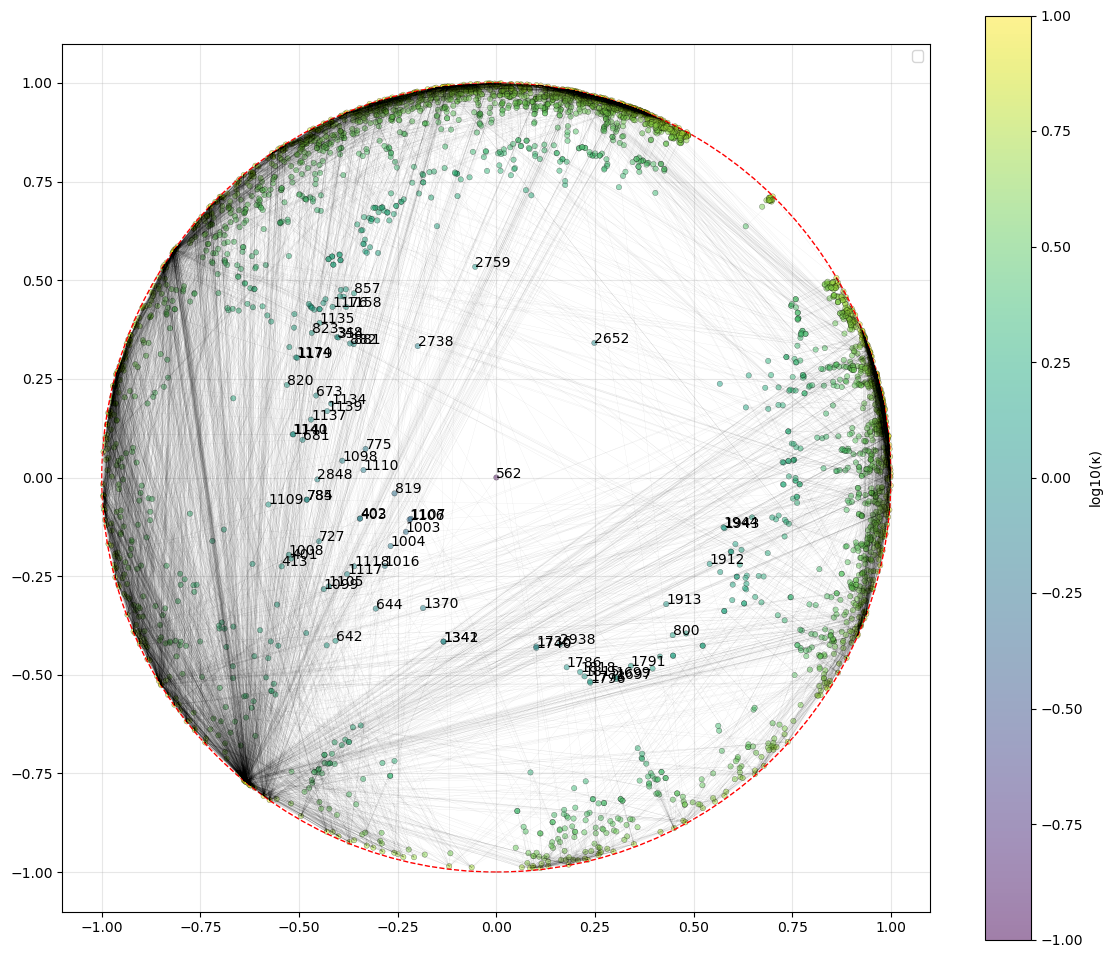

In [24]:
poincare_disc(lorentz_boost(df, '562', params['kappa_min']), params['kappa_min'], net=G)

In [43]:
! ./tools/epidemics -i 0.5 -s 7836580 -w -r 1.0 -m SIR -lt 50 -st -ev -sn 2652 -o ./pipeline-output ./epidemics-tfg/nets/inf-openflights_GC.edge_weight

 === Configuración de la simulación ===
 Archivo de red: ./epidemics-tfg/nets/inf-openflights_GC.edge_weight
 Nombre de red: inf-openflights_GC
 Modelo: SIR
 Infection rate:   0.50000000000000000     
 Recovery rate:    1.0000000000000000     
 Limit time:    50.000000000000000     
 Carpeta de output: ./pipeline-output
 Nodo inicial:         2652
 Seed:      7836580
 Weighted:  T
 Guardar stats:  T
 Guardar events:  T
 Initialized hash map
 Initialized degrees and pointers
 Initialized neighbour array
 Cleaned neighbours. Reduced neighbours by            0
 --- stats ---
N     =     2905
E     =    15645
<k>   =       10.77108434
<k^2> =      601.45266781
Var k =       22.03262150
Var w =        0.42607198
Filename will be inf-openflights_GC-wSIR-I=   0.50000-R=   1.00000-S=*****
 Initialized simulation
I/R=   0.50000-S=*****-t=start

Program received signal SIGSEGV: Segmentation fault - invalid memory reference.

Backtrace for this error:
#0  0xff8f71e5d44b in ???
#1  0xff8f71e5c2df 

In [5]:
events_file = './pipeline-output/events-inf-openflights_GC-SIR-I=   0.50000-R=   1.00000-S=*****.dat'

def skip_comments(line_index, line):
    # Saltar si la línea empieza con '#' o ' #'
    return line.strip().startswith('#') or line.lstrip().startswith('#')

with open(events_file, 'r') as f:
        lines = f.readlines()
    
    # Encontrar la primera línea de datos
first_data_line = 0
for i, line in enumerate(lines):
    if not line.lstrip().startswith('#'):
        first_data_line = i
        break

events = pd.read_csv(events_file, 
                        sep='\\s+', skiprows=first_data_line, names=['t', 'vertex', 'event'])
events['vertex'] = events['vertex'].astype(str)
events


,t,vertex,event
0,0.236661,2438,I
1,0.339316,66,I
2,0.353464,2433,I
3,0.355802,262,I
4,0.385671,268,I
...,...,...,...
3327,7.358077,1536,R
3328,7.366032,1738,R
3329,7.854404,1013,R
3330,7.950292,1057,R


In [ ]:
state = {str(v): 'H' for v in df['Vertex']}
epidemics_fig_output = './pipeline-output/out'
i = 0
stop_draw = False
while not stop_draw:
    t = (i+1)/100
    t_old = t-0.01
    ev = events[(events['t'] > t_old) & (events['t'] < t)]
    for ix, e in ev.iterrows():
        if (e['event'] == 'I'):
            state[e['vertex']] = 'I'
        elif (e['event'] == 'R'):
            state[e['vertex']] = 'H'
        elif (e['event'] == 'E'):
            stop_draw = True
        else:
            print('error')
    poincare_epidemic_disc(df, params['kappa_min'], False, state, f'{epidemics_fig_output}/sim-{i}.png', t)
    i = i+1


In [10]:
x = f"{epidemics_fig_output}/sim-%d.png"
! echo {x}

./pipeline-output/out/sim-%d.png


In [14]:
x1 = f"{epidemics_fig_output}/sim-%d.png"
x2 = f"{epidemics_fig_output}/../output.gif"
x3 = f"{epidemics_fig_output}/../palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/aarch64-linux-gnu --incdir=/usr/include/aarch64-linux-gnu --arch=arm64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --e